# Section1: Data Preparation and Validation

This section focuses on the essential preprocessing steps to prepare stock market time series data for modeling. It involves reading and combining raw yearly data, organizing it by individual stocks, cleaning missing or duplicate entries, and validating consistency.

The goal here is to transform unprocessed financial data into a clean, structured format that ensures accuracy and reliability for subsequent machine learning models.


In [25]:
import os
import numpy as np   
import pandas as pd
from typing import List, Optional

def read_and_concat_yearly_files(
    folder_path: str,
    columns: Optional[List[str]] = None
) -> pd.DataFrame:
    """
    Read parquet files in a folder and concatenate them vertically,
    selecting only `columns` if provided to save memory.

    Args:
        folder_path: Path to the folder containing parquet files.
        columns: List of column names to include. If None, all columns are read.

    Returns:
        Concatenated DataFrame with only selected columns.
    """
    files: List[str] = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.parquet')]

    # Read files with selected columns and concatenate
    df = pd.concat((pd.read_parquet(f, columns=columns) for f in files), ignore_index=True)
    return df

import pandas as pd

def split_to_stock_objects(df, ticker_col='ticker', permno_col='permno'):
    """
    Splits a DataFrame into a dictionary of Stock objects, one per ticker.

    Process:
    - Groups the DataFrame by ticker.
    - For each group, checks for a single unique permno.
    - Removes the identifier columns ('ticker', 'perno') from each subset.
    - Stores the resulting DataFrame and metadata as a Stock object.

    Args:
        df (pd.DataFrame): The input dataframe containing multiple stocks.
        ticker_col (str): Name of column with ticker symbol (default 'ticker').
        permno_col (str): Name of column with permno (default 'permno').

    Returns:
        dict: Keys are ticker symbols, values are Stock objects for each company.
    """
    stocks = {}
    for ticker, group in df.groupby(ticker_col):
        permnos = group[permno_col].unique()
        if len(permnos) == 1:
            permno = permnos[0]
        else:
            raise ValueError(f"Ticker '{ticker}' has multiple permnos: {permnos}")
        # Remove identifier columns
        stock_data = group.drop([ticker_col, permno_col], axis=1)
        stocks[ticker] = Stock(ticker, permno, stock_data)
    return stocks

class Stock:
    """
    Represents the data for a single stock.

    Attributes:
        ticker (str): Ticker symbol of the stock (e.g., 'AAPL').
        permno (int/str): Unique permanent number assigned to the stock.
        data (pd.DataFrame): DataFrame containing all stock-specific data except identifiers.
    """
    def __init__(self, ticker, permno, data):
        self.ticker = ticker
        self.permno = permno
        self.data = data.reset_index(drop=True)  # DataFrame without identifier columns
        # One dictionary to hold all models and their related info (features, metrics, etc.)
        self.model_info = {}  # e.g., {'regression_model': {'model': model_obj, 'input_data': df, ...}, ...}

    def __repr__(self):
        return f"Stock(ticker='{self.ticker}', permno={self.permno}, data_shape={self.data.shape})"
    
    def clean_and_forward_fill(self, date_col='date'):
        """
        Cleans and forward fills the stock's time series DataFrame stored in self.data.

        Steps:
        - Converts the date column to datetime
        - Sorts by date ascending
        - Removes duplicate dates, keeping first (temporary fix)
        - Drops leading rows with any missing values to allow forward fill
        - Forward fills remaining missing values (useful for mixed frequency data)
        """
        # Convert the date column to datetime format to ensure proper date handling
        self.data[date_col] = pd.to_datetime(self.data[date_col])

        # Sort the DataFrame by the date column in ascending order
        self.data = self.data.sort_values(by=date_col)

        # Remove duplicate rows based on the date column, keeping only the first occurrence
        self.data = self.data.drop_duplicates(subset=[date_col], keep='first')

        # Drops all rows from the start until the first row with complete data (no NaNs)
        self.data = self.data.loc[~self.data.isnull().any(axis=1)].reset_index(drop=True)

        # Forward fill remaining missing values in the DataFrame
        self.data = self.data.ffill()



    def validate_data_consistency(self, date_col='date') -> None:
        """
        Validates the time series DataFrame before further passing it to a model.

        Checks include:
        - Presence of date column
        - Date column dtype is datetime
        - Dates sorted ascending and unique
        - No missing values
        - Expected numeric columns only

        Raises ValueError if any check fails.
        Prints confirmation if all checks pass.

        Args:
            date_col (str): Name of the date column in the data.
        """
        df = self.data

        # Check date column presence
        if date_col not in df.columns:
            raise ValueError(f"Date column '{date_col}' not found in dataframe.")

        # Check date column dtype
        if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
            raise ValueError(f"Date column '{date_col}' must be datetime type.")

        # Check if sorted and unique
        if not df[date_col].is_monotonic_increasing:
            raise ValueError(f"Date column '{date_col}' must be sorted in ascending order.")
        if df[date_col].duplicated().any():
            raise ValueError(f"Duplicate dates found in '{date_col}' column.")

        # Check for missing values
        if df.isnull().any().any():
            missing_cols = df.columns[df.isnull().any()].tolist()
            raise ValueError(f"Missing values detected in columns: {missing_cols}")

        # Check numeric columns (excluding date) for numeric dtype
        non_date_cols = df.columns.difference([date_col])
        for col in non_date_cols:
            if not pd.api.types.is_numeric_dtype(df[col]):
                raise ValueError(f"Column '{col}' must be numeric type.")

        print("Data Consistency validation passed: all checks are OK.")

    def add_model(self, model_name, model_obj, input_data):
        pass







we read and process stock data from parquet files and then display the raw imported data



In [26]:
folder_path=r"src\wrds_extracts\run_20250913_163841\final_20250913_164200"
columns = ['permno','ticker','date','crsp_prc','crsp_ret','crsp_cfacpr','shs_traded_q', 'shs_out_q', 'mkt_value_q','sales_q','revenue_q', 'cogs_q', 'sga_q', 'rd_exp_q', 'ff_mkt_rf',
       'ff_smb', 'ff_hml', 'ff_mom', 'ff_rf']
df = read_and_concat_yearly_files(folder_path,columns)
display(df)

,permno,ticker,date,crsp_prc,crsp_ret,crsp_cfacpr,shs_traded_q,shs_out_q,mkt_value_q,sales_q,revenue_q,cogs_q,sga_q,rd_exp_q,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf
0,14593,AAPL,2010-12-31,322.56000,-0.003399,28.0,1.020304e+09,921.035,297089.0496,26741.0,26741.0,16087.0,2471.0,575.0,-0.0010,-0.0063,0.0022,-0.0016,0.00001
1,10107,MSFT,2010-12-20,27.81000,-0.003315,1.0,3.957018e+09,8562.000,209683.3800,16195.0,16195.0,2445.0,5940.0,2196.0,0.0023,-0.0001,0.0030,0.0006,0.00001
2,14593,AAPL,2010-11-11,316.65500,-0.004323,28.0,1.321636e+09,915.970,259906.4875,20343.0,20343.0,12502.0,2065.0,494.0,-0.0035,-0.0010,-0.0012,0.0030,0.00001
3,10107,MSFT,2010-11-17,25.57000,-0.009299,1.0,3.957018e+09,8562.000,209683.3800,16195.0,16195.0,2445.0,5940.0,2196.0,0.0007,0.0034,-0.0026,0.0052,0.00001
4,10107,MSFT,2010-10-28,26.28000,0.008829,1.0,3.957018e+09,8562.000,209683.3800,16195.0,16195.0,2445.0,5940.0,2196.0,0.0008,-0.0062,-0.0008,0.0007,0.00001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119367,14593,AAPL,2020-11-25,116.03000,0.007467,1.0,1.355319e+09,909.636,213764.4600,13499.0,13499.0,7658.0,1646.0,426.0,0.0002,0.0000,-0.0132,0.0153,0.00000
119368,10107,MSFT,2020-10-02,206.19000,-0.029512,1.0,3.536551e+09,8762.000,256617.0750,14503.0,14503.0,2061.0,6575.0,2220.0,-0.0097,0.0108,0.0243,-0.0271,0.00000
119369,14593,AAPL,2020-03-27,247.74001,-0.041402,4.0,1.355319e+09,909.636,213764.4600,13499.0,13499.0,7658.0,1646.0,426.0,-0.0348,-0.0086,-0.0076,0.0098,0.00006
119370,10107,MSFT,2020-02-25,168.07001,-0.016502,1.0,3.536551e+09,8762.000,256617.0750,14503.0,14503.0,2061.0,6575.0,2220.0,-0.0309,-0.0011,-0.0068,0.0076,0.00006


Now we create our stock classes using the raw data, clean the data for each stock and validate them and display the head of the dataframe for each stock.

In [27]:
stocks = split_to_stock_objects(df, ticker_col='ticker', permno_col='permno')
print("the list of stocks:\n", stocks,'\n\n')
for i in stocks:
    print(stocks[i].ticker)
    stocks[i].clean_and_forward_fill(date_col='date')
    stocks[i].validate_data_consistency(date_col='date')
    display(stocks[i].data.head())

the list of stocks:
 {'AAPL': Stock(ticker='AAPL', permno=14593, data_shape=(59686, 17)), 'MSFT': Stock(ticker='MSFT', permno=10107, data_shape=(59686, 17))} 


AAPL
Data Consistency validation passed: all checks are OK.


,date,crsp_prc,crsp_ret,crsp_cfacpr,shs_traded_q,shs_out_q,mkt_value_q,sales_q,revenue_q,cogs_q,sga_q,rd_exp_q,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf
0,2010-03-31,235.00000,-0.003583,28.0,1.355319e+09,909.636,213764.46,13499.0,13499.0,7658.0,1646.0,426.0,-0.0036,-0.0051,0.0020,-0.0014,0.00000
1,2010-04-01,235.97000,0.004128,28.0,1.355319e+09,909.636,213764.46,13499.0,13499.0,7658.0,1646.0,426.0,0.0075,-0.0005,0.0079,0.0063,0.00001
2,2010-04-05,238.49001,0.010679,28.0,1.355319e+09,909.636,213764.46,13499.0,13499.0,7658.0,1646.0,426.0,0.0095,0.0105,0.0085,0.0102,0.00001
3,2010-04-06,239.53999,0.004403,28.0,1.355319e+09,909.636,213764.46,13499.0,13499.0,7658.0,1646.0,426.0,0.0019,0.0025,0.0047,0.0024,0.00001
4,2010-04-07,240.60001,0.004425,28.0,1.355319e+09,909.636,213764.46,13499.0,13499.0,7658.0,1646.0,426.0,-0.0048,0.0019,0.0027,-0.0043,0.00001


MSFT
Data Consistency validation passed: all checks are OK.


,date,crsp_prc,crsp_ret,crsp_cfacpr,shs_traded_q,shs_out_q,mkt_value_q,sales_q,revenue_q,cogs_q,sga_q,rd_exp_q,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf
0,2010-03-31,29.2875,-0.016208,1.0,3.536551e+09,8762.0,256617.075,14503.0,14503.0,2061.0,6575.0,2220.0,-0.0036,-0.0051,0.0020,-0.0014,0.00000
1,2010-04-01,29.1600,-0.004353,1.0,3.536551e+09,8762.0,256617.075,14503.0,14503.0,2061.0,6575.0,2220.0,0.0075,-0.0005,0.0079,0.0063,0.00001
2,2010-04-05,29.2700,0.003772,1.0,3.536551e+09,8762.0,256617.075,14503.0,14503.0,2061.0,6575.0,2220.0,0.0095,0.0105,0.0085,0.0102,0.00001
3,2010-04-06,29.3200,0.001708,1.0,3.536551e+09,8762.0,256617.075,14503.0,14503.0,2061.0,6575.0,2220.0,0.0019,0.0025,0.0047,0.0024,0.00001
4,2010-04-07,29.3500,0.001023,1.0,3.536551e+09,8762.0,256617.075,14503.0,14503.0,2061.0,6575.0,2220.0,-0.0048,0.0019,0.0027,-0.0043,0.00001


# Section2 : Feature Extraction

In [31]:
import numpy as np
import pandas as pd

def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts meaningful features from raw stock data.

    Steps:
    - Creates adjusted prices using crsp_prc * crsp_cfacpr
    - Computes log returns based on adjusted prices
    - Uses raw crsp_ret as is
    - Calculates simple returns for volume and fundamental columns
    - Includes factor return columns unchanged
    - Drops rows with NaNs caused by lag operations

    Args:
        df (pd.DataFrame): Raw stock data with specified columns.

    Returns:
        pd.DataFrame: DataFrame with constructed feature columns only.
    """
    df = df.copy()
    
    # Calculate adjusted price first
    df['adj_price'] = df['crsp_prc'] / df['crsp_cfacpr']
    
    # Compute log return on adjusted price
    df['log_return_prc'] = np.log(df['adj_price']) - np.log(df['adj_price'].shift(1))

    # Columns for which to compute simple returns (change divided by previous)
    cols_returns = [
        'shs_traded_q', 'shs_out_q', 'mkt_value_q', 'sales_q', 'revenue_q',
        'cogs_q', 'sga_q', 'rd_exp_q'
    ]

    for col in cols_returns:
        df[col + '_return'] = df[col].pct_change()  # Same as (x_t - x_{t-1})/x_{t-1}

    # Factor returns used directly as features
    factor_cols = ['ff_mkt_rf', 'ff_smb', 'ff_hml', 'ff_mom', 'ff_rf']

    # Select feature columns for output
    feature_cols = ['log_return_prc'] \
                   + [col + '_return' for col in cols_returns] \
                   + factor_cols

    # Drop rows with any missing values caused by lag operations
    features = df[feature_cols].dropna().reset_index(drop=True)

    return features


# Section 3.1: Regression Model

In [42]:
for ticker in stocks:
    # Extract features from raw stock data of the current stock
    features = extract_features(stocks[ticker].data)
    
    # Add target label (next period's log_return_prc)
    features['target'] = features['log_return_prc'].shift(-1)
    features = features.dropna(subset=['target']).reset_index(drop=True)
    
    # Store the features with targets as input_data for a model named 'regression_model'
    model_name = 'regression_model'
    if model_name not in stocks[ticker].model_info:
        stocks[ticker].model_info[model_name] = {}
    stocks[ticker].model_info[model_name]['input_data'] = features
    print(f"Preparing regression model input data for {ticker}")
    display(stocks[ticker].model_info['regression_model']['input_data'])

Preparing regression model input data for AAPL


,log_return_prc,shs_traded_q_return,shs_out_q_return,mkt_value_q_return,sales_q_return,revenue_q_return,cogs_q_return,sga_q_return,rd_exp_q_return,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf,target
0,0.004119,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0075,-0.0005,0.0079,0.0063,0.00001,0.010623
1,0.010623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0095,0.0105,0.0085,0.0102,0.00001,0.004393
2,0.004393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0019,0.0025,0.0047,0.0024,0.00001,0.004415
3,0.004415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.0048,0.0019,0.0027,-0.0043,0.00001,-0.002705
4,-0.002705,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0031,-0.0029,0.0035,0.0026,0.00001,0.007639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,-0.007000,-0.467361,-0.831335,-0.585396,-0.681312,-0.681312,-0.677232,-0.725712,-0.833594,0.0011,0.0039,0.0204,-0.0224,0.00000,0.007683
2703,0.007683,-0.024853,0.006963,0.215855,0.507001,0.507001,0.632541,0.254557,0.159624,0.0023,-0.0040,-0.0019,0.0021,0.00000,0.035141
2704,0.035141,0.025486,-0.006915,-0.177533,-0.336430,-0.336430,-0.387458,-0.202906,-0.137652,0.0049,-0.0073,0.0036,-0.0048,0.00000,-0.013404
2705,-0.013404,0.237664,0.004228,0.074866,0.163049,0.163049,0.213241,0.155529,0.089202,-0.0039,-0.0152,0.0024,-0.0041,0.00000,-0.008563


Preparing regression model input data for MSFT


,log_return_prc,shs_traded_q_return,shs_out_q_return,mkt_value_q_return,sales_q_return,revenue_q_return,cogs_q_return,sga_q_return,rd_exp_q_return,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf,target
0,-0.004363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0075,-0.0005,0.0079,0.0063,0.00001,0.003765
1,0.003765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0095,0.0105,0.0085,0.0102,0.00001,0.001707
2,0.001707,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0019,0.0025,0.0047,0.0024,0.00001,0.001023
3,0.001023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.0048,0.0019,0.0027,-0.0043,0.00001,0.019235
4,0.019235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0031,-0.0029,0.0035,0.0026,0.00001,0.013940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,-0.013125,-0.273467,-0.047208,0.456315,0.188550,0.188550,0.369996,0.030319,0.026139,0.0011,0.0039,0.0204,-0.0224,0.00000,0.007797
2703,0.007797,-0.181398,-0.000906,0.058905,-0.101216,-0.101216,-0.275113,0.050998,0.095689,0.0023,-0.0040,-0.0019,0.0021,0.00000,0.009873
2704,0.009873,1.786453,0.108637,-0.587754,-0.302301,-0.302301,-0.563938,-0.295290,-0.345455,0.0049,-0.0073,0.0036,-0.0048,0.00000,-0.003607
2705,-0.003607,-0.610963,-0.108386,4.061703,1.041062,1.041062,2.040900,0.677273,1.078780,-0.0039,-0.0152,0.0024,-0.0041,0.00000,-0.011081


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

for ticker in stocks:
    print(f"Training regression model for {ticker}...")
    
    # Retrieve input data (features + target)
    data = stocks[ticker].model_info['regression_model']['input_data']
    
    # Separate features (X) and target (y)
    X = data.drop(columns=['target'])
    y = data['target']
    
    # Split into train and test sets (e.g., 80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Initialize and train regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Evaluate model with Mean Squared Error (MSE)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{ticker} test MSE: {mse:.6f}")
    
    # Store the trained model in the stock's model_info dictionary
    stocks[ticker].model_info['regression_model']['model'] = model


Training regression model for AAPL...
AAPL test MSE: 0.000590
Training regression model for MSFT...
MSFT test MSE: 0.000464


# Section 3.2: Logistic Regression Model

In [46]:
for ticker in stocks:
    # Extract features from raw stock data of the current stock
    features = extract_features(stocks[ticker].data)
    
    # Create binary target: 1 if next period’s log_return_prc > 0 else 0
    features['target'] = (features['log_return_prc'].shift(-1) > 0).astype(int)
    features = features.dropna(subset=['target']).reset_index(drop=True)
    
    # Store the features with target_class as input_data for 'logistic_regression_model'
    model_name = 'logistic_regression_model'
    if model_name not in stocks[ticker].model_info:
        stocks[ticker].model_info[model_name] = {}
    stocks[ticker].model_info[model_name]['input_data'] = features
    
    print(f"Preparing logistic regression model input data for {ticker}")
    display(stocks[ticker].model_info['logistic_regression_model']['input_data'])

Preparing logistic regression model input data for AAPL


,log_return_prc,shs_traded_q_return,shs_out_q_return,mkt_value_q_return,sales_q_return,revenue_q_return,cogs_q_return,sga_q_return,rd_exp_q_return,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf,target
0,0.004119,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0075,-0.0005,0.0079,0.0063,0.00001,1
1,0.010623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0095,0.0105,0.0085,0.0102,0.00001,1
2,0.004393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0019,0.0025,0.0047,0.0024,0.00001,1
3,0.004415,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.0048,0.0019,0.0027,-0.0043,0.00001,0
4,-0.002705,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0031,-0.0029,0.0035,0.0026,0.00001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.007683,-0.024853,0.006963,0.215855,0.507001,0.507001,0.632541,0.254557,0.159624,0.0023,-0.0040,-0.0019,0.0021,0.00000,1
2704,0.035141,0.025486,-0.006915,-0.177533,-0.336430,-0.336430,-0.387458,-0.202906,-0.137652,0.0049,-0.0073,0.0036,-0.0048,0.00000,0
2705,-0.013404,0.237664,0.004228,0.074866,0.163049,0.163049,0.213241,0.155529,0.089202,-0.0039,-0.0152,0.0024,-0.0041,0.00000,0
2706,-0.008563,0.680024,4.997322,1.598689,2.220191,2.220191,2.030782,2.119874,4.411638,0.0027,0.0101,0.0006,-0.0025,0.00000,0


Preparing logistic regression model input data for MSFT


,log_return_prc,shs_traded_q_return,shs_out_q_return,mkt_value_q_return,sales_q_return,revenue_q_return,cogs_q_return,sga_q_return,rd_exp_q_return,ff_mkt_rf,ff_smb,ff_hml,ff_mom,ff_rf,target
0,-0.004363,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0075,-0.0005,0.0079,0.0063,0.00001,1
1,0.003765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0095,0.0105,0.0085,0.0102,0.00001,1
2,0.001707,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0019,0.0025,0.0047,0.0024,0.00001,1
3,0.001023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.0048,0.0019,0.0027,-0.0043,0.00001,1
4,0.019235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0031,-0.0029,0.0035,0.0026,0.00001,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2703,0.007797,-0.181398,-0.000906,0.058905,-0.101216,-0.101216,-0.275113,0.050998,0.095689,0.0023,-0.0040,-0.0019,0.0021,0.00000,1
2704,0.009873,1.786453,0.108637,-0.587754,-0.302301,-0.302301,-0.563938,-0.295290,-0.345455,0.0049,-0.0073,0.0036,-0.0048,0.00000,0
2705,-0.003607,-0.610963,-0.108386,4.061703,1.041062,1.041062,2.040900,0.677273,1.078780,-0.0039,-0.0152,0.0024,-0.0041,0.00000,0
2706,-0.011081,1.384719,0.100734,-0.779030,-0.396370,-0.396370,-0.439139,-0.301917,-0.521358,0.0027,0.0101,0.0006,-0.0025,0.00000,1


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report



# Train the logistic regression models
for ticker in stocks:
    print(f"Training logistic regression model for {ticker}...")
    
    data = stocks[ticker].model_info['logistic_regression_model']['input_data']
    X = data.drop(columns=['target'])
    y = data['target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{ticker} test accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    stocks[ticker].model_info['logistic_regression_model']['model'] = model


Training logistic regression model for AAPL...
AAPL test accuracy: 0.5129
              precision    recall  f1-score   support

           0       0.42      0.19      0.26       246
           1       0.54      0.78      0.64       296

    accuracy                           0.51       542
   macro avg       0.48      0.49      0.45       542
weighted avg       0.48      0.51      0.47       542

Training logistic regression model for MSFT...
MSFT test accuracy: 0.5258
              precision    recall  f1-score   support

           0       0.42      0.27      0.33       232
           1       0.57      0.72      0.63       310

    accuracy                           0.53       542
   macro avg       0.49      0.49      0.48       542
weighted avg       0.50      0.53      0.50       542



Text(0.5, 0, 'Date')

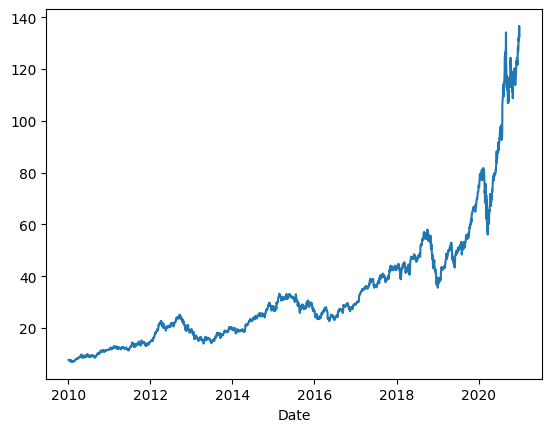

In [6]:
#plot same but for adjusted price
plt.plot(df_14593['date'], df_14593['crsp_prc_adj'])
plt.xlabel('Date')